In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(r"D:\Ultimate Programming\Data Bases\Machine Learning Datasets\Cleaned Dataset\Early Disease Detection.xlsx")
df.head(3)

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,2021-03-05,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62,0
1,2021-05-08,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85,1
2,2022-11-13,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64,1


In [3]:
max(df['date'])

Timestamp('2023-01-01 00:00:00')

In [4]:
print((df.isnull().sum().sum() / df.shape[0]) * 100)

0.0


In [5]:
print(df.duplicated().sum())

0


In [6]:
df['disease'].value_counts()

disease
0    35021
1    34979
Name: count, dtype: int64

In [7]:
df.describe()

,date,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,2020-07-01 14:26:20.708571392,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205543,0.499700
min,2018-01-01 00:00:00,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,2019-04-03 00:00:00,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,2020-06-30 00:00:00,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,2021-10-02 00:00:00,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,2023-01-01 00:00:00,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000
std,NaN,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395829,0.500003


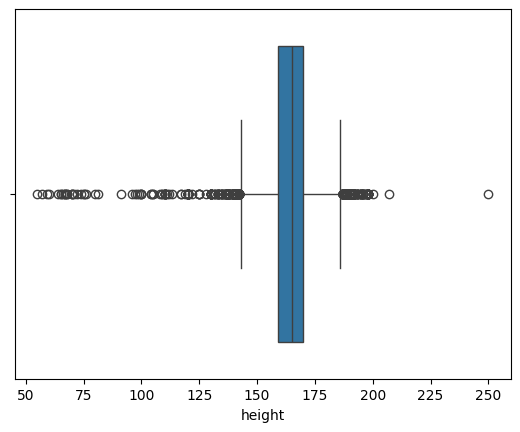

In [8]:
sns.boxplot(data=df, x='height')
plt.show()

In [9]:
cols = ['ap_hi', 'ap_lo', 'height', 'weight']

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    min_range = q1 - (iqr*1.5)
    max_range = q3 + (iqr*1.5)
    print(min_range, max_range)
    df = df[df[col] <= max_range]
    df = df[df[col] >= min_range]

90.0 170.0
65.0 105.0
142.5 186.5
39.5 107.5


In [10]:
df.shape

(62505, 16)

In [11]:
x = df.drop(columns=['date', 'id'])
y = df['disease']

In [12]:
x.head(2)

,country,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,Indonesia,1,18393,0,110,80,1,2,1,168,Architect,0,62,0
1,Malaysia,1,20228,0,140,90,3,1,1,156,Accountant,0,85,1


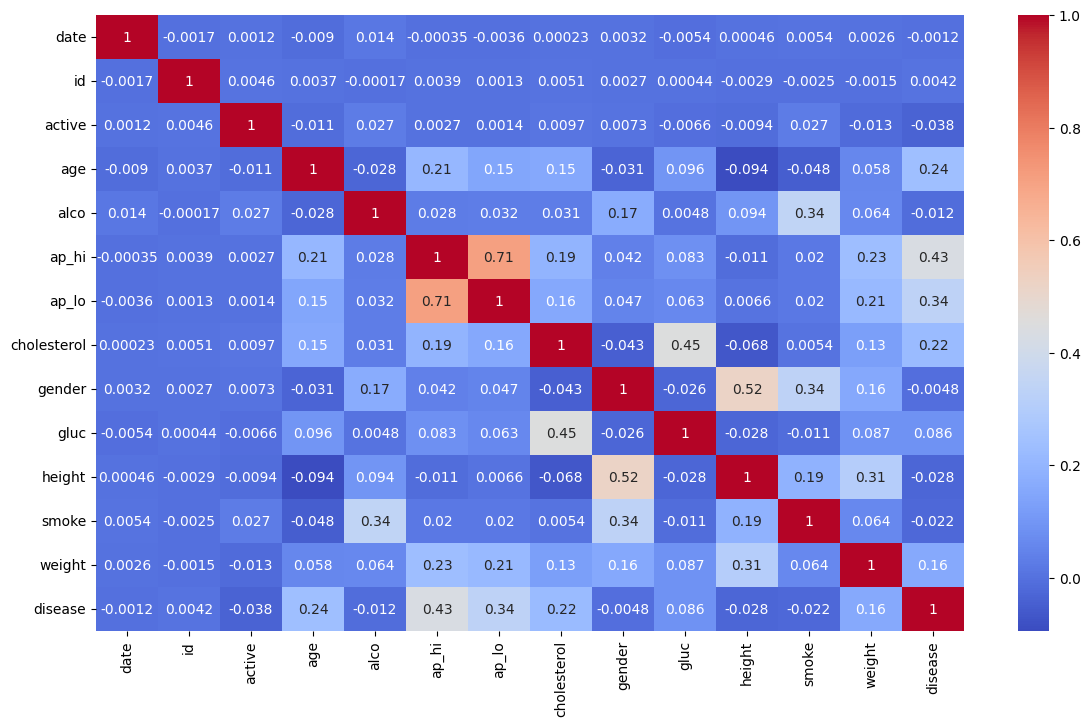

In [13]:
num_col = df.drop(columns=['country', 'occupation'])
plt.figure(figsize=(14,8))
sns.heatmap(data=num_col.corr(), annot=True, cmap='coolwarm')
plt.show()

In [14]:
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

In [15]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62505 entries, 0 to 69999
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   country      62505 non-null  object
 1   active       62505 non-null  int64 
 2   age          62505 non-null  int64 
 3   alco         62505 non-null  int64 
 4   ap_hi        62505 non-null  int64 
 5   ap_lo        62505 non-null  int64 
 6   cholesterol  62505 non-null  int64 
 7   gender       62505 non-null  int64 
 8   gluc         62505 non-null  int64 
 9   height       62505 non-null  int64 
 10  occupation   62505 non-null  object
 11  smoke        62505 non-null  int64 
 12  weight       62505 non-null  int64 
 13  disease      62505 non-null  int64 
dtypes: int64(12), object(2)
memory usage: 7.2+ MB


In [16]:
ct = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(drop='first', dtype=np.int16), [0, 10])
], remainder='passthrough')

In [17]:
ct.fit(x)
x_enc = ct.transform(x)
x_en = pd.DataFrame(x_enc, columns=ct.get_feature_names_out())

In [18]:
x_en.head(3)

,ohe__country_Indonesia,ohe__country_Malaysia,ohe__country_Singapore,ohe__occupation_Architect,ohe__occupation_Chef,ohe__occupation_Doctor,ohe__occupation_Engineer,ohe__occupation_Lawyer,ohe__occupation_Nurse,ohe__occupation_Others,...,remainder__alco,remainder__ap_hi,remainder__ap_lo,remainder__cholesterol,remainder__gender,remainder__gluc,remainder__height,remainder__smoke,remainder__weight,remainder__disease
0,1,0,0,1,0,0,0,0,0,0,...,0,110,80,1,2,1,168,0,62,0
1,0,1,0,0,0,0,0,0,0,0,...,0,140,90,3,1,1,156,0,85,1
2,1,0,0,0,1,0,0,0,0,0,...,0,130,70,3,1,1,165,0,64,1


In [19]:
x_train, x_test, y_train, y_test = train_test_split(x_en, y, test_size=0.2, random_state=42)

In [20]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
print(f"Training Accuracy: {round(dt.score(x_train, y_train)*100, 2)}")
print(f"Testing Accuracy: {round(dt.score(x_test, y_test)*100, 2)}")

Training Accuracy: 100.0
Testing Accuracy: 100.0


In [22]:
import xgboost as xgb
xg = xgb.XGBClassifier(
    n_estimators=100,       
    learning_rate=0.1,     
    max_depth=4,           
    subsample=0.8,          
    colsample_bytree=0.8,   
    random_state=42
)

xg.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
print(f"Training Accuracy: {round(dt.score(x_train, y_train)*100, 2)}")
print(f"Testing Accuracy: {round(dt.score(x_test, y_test)*100, 2)}")

Training Accuracy: 100.0
Testing Accuracy: 100.0


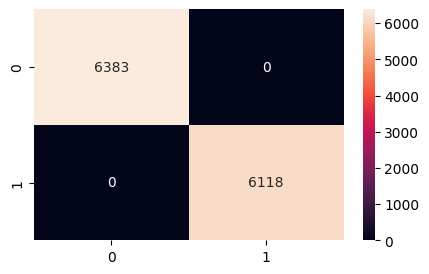

In [24]:
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, xg.predict(x_test)), annot=True, fmt='.0f')
plt.show()

In [25]:
from sklearn.model_selection import KFold, cross_val_score

dt = DecisionTreeClassifier()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(dt, x_train, y_train, cv=kf, scoring='accuracy')*100

scores.sort()
print("Cross-validation scores for each fold:", scores)
print("Mean Accuracy:", np.mean(scores))
print("Standard Deviation:", np.std(scores))

Cross-validation scores for each fold: [100. 100. 100. 100. 100.]
Mean Accuracy: 100.0
Standard Deviation: 0.0
